In [141]:
# ----------------------------
# Import required libraries
# ----------------------------

# For data manipulation
import pandas as pd

# For numerical operations
import numpy as np

# For uploading files in Google Colab
from google.colab import files

# For plotting (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
# This will open a file chooser dialog
uploaded = files.upload()  # Upload your CSV or Excel file

Saving Healthcare_project_(csv).csv to Healthcare_project_(csv) (3).csv


In [143]:
# Load the uploaded file into a pandas DataFrame
# Replace 'YourFileName.csv' with the exact name of the uploaded file
df = pd.read_csv(list(uploaded.keys())[0])

In [144]:
# Quick inspection of the dataset
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Date of Discharge,Hospital,Admission Type,Doctor,Room Number,Test Results,Medication,Insurance Provider,Billing Amount
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,02-02-2024,Sons and Miller,Urgent,Matthew Smith,328,Normal,Doxorubicin,Blue Cross,18856.28131
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,26-08-2019,Kim Inc,Elective,Samantha Davies,265,Inconclusive,Orlistat,Medicare,33643.32729
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,07-10-2022,Cook PLC,Elective,Tiffany Mitchell,205,Normal,Orlistat,Aetna,27955.09608
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,18-12-2020,"Hernandez Rogers and Vang,",Elective,Kevin Wells,450,Abnormal,Metformin,Medicare,37909.78241
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,09-10-2022,White-White,Urgent,Kathleen Hanna,458,Abnormal,Doxorubicin,Aetna,14238.31781


In [145]:
print(df.info()) # Shows column names, data types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood Type          54966 non-null  object 
 4   Medical Condition   54966 non-null  object 
 5   Date of Admission   54966 non-null  object 
 6   Date of Discharge   54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Admission Type      54966 non-null  object 
 9   Doctor              54966 non-null  object 
 10  Room Number         54966 non-null  int64  
 11  Test Results        54966 non-null  object 
 12  Medication          54966 non-null  object 
 13  Insurance Provider  54966 non-null  object 
 14  Billing Amount      54966 non-null  float64
dtypes: float64(1), int64(2), object(12)
memory usage: 6.3

In [146]:
print(df.describe())  # Shows statistical summary (mean, min, max, etc.) of numeric column

                Age   Room Number  Billing Amount
count  54966.000000  54966.000000    54966.000000
mean      51.535185    301.124404    25544.306284
std       19.605661    115.223143    14208.409711
min       13.000000    101.000000    -2008.492140
25%       35.000000    202.000000    13243.718638
50%       52.000000    302.000000    25542.749145
75%       68.000000    401.000000    37819.858157
max       89.000000    500.000000    52764.276740


In [147]:
print(df.drop(columns=['Room Number']).describe())  # Shows stats without Room Number column

                Age  Billing Amount
count  54966.000000    54966.000000
mean      51.535185    25544.306284
std       19.605661    14208.409711
min       13.000000    -2008.492140
25%       35.000000    13243.718638
50%       52.000000    25542.749145
75%       68.000000    37819.858157
max       89.000000    52764.276740


In [148]:
# Add a serial number column at the first position
df.insert(0, 'ID', range(1, len(df) + 1))

# Check the result
df.head()

,ID,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Date of Discharge,Hospital,Admission Type,Doctor,Room Number,Test Results,Medication,Insurance Provider,Billing Amount
0,1,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,02-02-2024,Sons and Miller,Urgent,Matthew Smith,328,Normal,Doxorubicin,Blue Cross,18856.28131
1,2,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,26-08-2019,Kim Inc,Elective,Samantha Davies,265,Inconclusive,Orlistat,Medicare,33643.32729
2,3,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,07-10-2022,Cook PLC,Elective,Tiffany Mitchell,205,Normal,Orlistat,Aetna,27955.09608
3,4,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,18-12-2020,"Hernandez Rogers and Vang,",Elective,Kevin Wells,450,Abnormal,Metformin,Medicare,37909.78241
4,5,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,09-10-2022,White-White,Urgent,Kathleen Hanna,458,Abnormal,Doxorubicin,Aetna,14238.31781


In [149]:
df.isnull().sum()  # Shows number of missing values in each column

,0
ID,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Date of Discharge,0
Hospital,0
Admission Type,0


In [150]:
print(df.duplicated().sum())  # Check how many duplicate rows exist

0


In [151]:
df.dtypes  # Shows data types of each column

,0
ID,int64
Name,object
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,object
Date of Discharge,object
Hospital,object
Admission Type,object


In [152]:
# Convert date columns to datetime
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], dayfirst=True)
df['Date of Discharge'] = pd.to_datetime(df['Date of Discharge'], dayfirst=True)

In [153]:
df.dtypes  # Check if dates are now datetime64

,0
ID,int64
Name,object
Age,int64
Gender,object
Blood Type,object
Medical Condition,object
Date of Admission,datetime64[ns]
Date of Discharge,datetime64[ns]
Hospital,object
Admission Type,object


In [154]:
cat_cols = ['Gender', 'Blood Type', 'Medical Condition',
            'Admission Type', 'Test Results',
            'Medication', 'Insurance Provider']

df[cat_cols] = df[cat_cols].astype('category')  # Convert to category

In [155]:
df.dtypes  # Verify all types

,0
ID,int64
Name,object
Age,int64
Gender,category
Blood Type,category
Medical Condition,category
Date of Admission,datetime64[ns]
Date of Discharge,datetime64[ns]
Hospital,object
Admission Type,category


In [156]:
# Calculate Length of Stay
df['Length of Stay'] = (df['Date of Discharge'] - df['Date of Admission']).dt.days

# Check result
df[['Date of Admission', 'Date of Discharge', 'Length of Stay']].head()

,Date of Admission,Date of Discharge,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [157]:
print((df['Length of Stay'] < 0).sum())  # Count negative values

0


In [158]:
pd.crosstab(df['Medical Condition'], df['Medication'])

Medication,Amlodipine,Doxorubicin,Ibuprofen,Metformin,Orlistat,Salbutamol
Medical Condition,,,,,,
Arthritis,0,0,2821,0,0,0
Asthma,0,0,0,0,0,9095
Cancer,0,7568,0,0,0,0
Diabetes,0,0,0,11219,0,0
Hypertension,14471,0,0,0,0,0
Obesity,0,0,0,0,9792,0


In [159]:
print("=== Gender Distribution ===")
print(df['Gender'].value_counts())

print("\n=== Medical Condition Distribution ===")
print(df['Medical Condition'].value_counts())

print("\n=== Billing Summary ===")
print(df['Billing Amount'].describe())

=== Gender Distribution ===
Gender
Male      35802
Female    19164
Name: count, dtype: int64

=== Medical Condition Distribution ===
Medical Condition
Hypertension    14471
Diabetes        11219
Obesity          9792
Asthma           9095
Cancer           7568
Arthritis        2821
Name: count, dtype: int64

=== Billing Summary ===
count    54966.000000
mean     25544.306284
std      14208.409711
min      -2008.492140
25%      13243.718638
50%      25542.749145
75%      37819.858157
max      52764.276740
Name: Billing Amount, dtype: float64


In [160]:
print((df['Billing Amount'] < 0).sum())  # Count negative values

106


In [161]:
df = df[df['Billing Amount'] >= 0]  # Remove negative billing rows
print((df['Billing Amount'] < 0).sum())  # Should be 0

0


In [162]:
df['Billing Amount'].map('${:,.2f}'.format)  # Formats values as $ with 2 decimals

,Billing Amount
0,"$18,856.28"
1,"$33,643.33"
2,"$27,955.10"
3,"$37,909.78"
4,"$14,238.32"
...,...
54961,"$2,650.71"
54962,"$31,457.80"
54963,"$27,620.76"
54964,"$32,451.09"


In [163]:
df['Billing Amount'].describe()

,Billing Amount
count,54860.000000
mean,25594.633637
std,14175.867041
min,9.238787
25%,13299.747943
50%,25593.872995
75%,37847.066672
max,52764.276740


In [164]:
# Standardize text columns (capitalize properly)
text_cols = ['Name', 'Doctor', 'Hospital']

for col in text_cols:
    df[col] = df[col].str.title()  # Convert to proper case

In [165]:
# Check the Final result
df.head()

,ID,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Date of Discharge,Hospital,Admission Type,Doctor,Room Number,Test Results,Medication,Insurance Provider,Billing Amount,Length of Stay
0,1,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,2024-02-02,Sons And Miller,Urgent,Matthew Smith,328,Normal,Doxorubicin,Blue Cross,18856.28131,2
1,2,Leslie Terry,62,Male,A+,Obesity,2019-08-20,2019-08-26,Kim Inc,Elective,Samantha Davies,265,Inconclusive,Orlistat,Medicare,33643.32729,6
2,3,Danny Smith,76,Female,A-,Obesity,2022-09-22,2022-10-07,Cook Plc,Elective,Tiffany Mitchell,205,Normal,Orlistat,Aetna,27955.09608,15
3,4,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,2020-12-18,"Hernandez Rogers And Vang,",Elective,Kevin Wells,450,Abnormal,Metformin,Medicare,37909.78241,30
4,5,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,2022-10-09,White-White,Urgent,Kathleen Hanna,458,Abnormal,Doxorubicin,Aetna,14238.31781,20


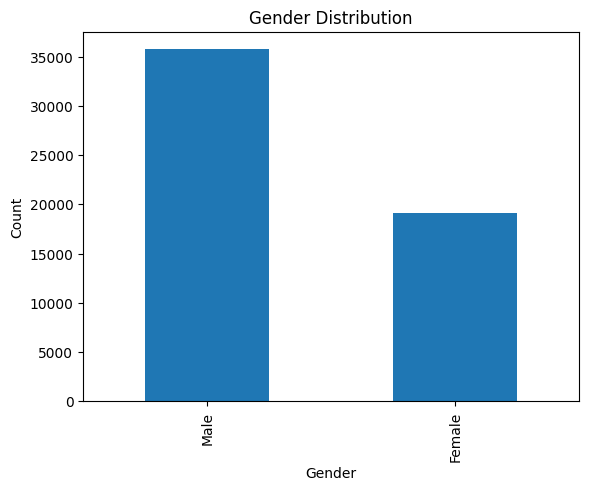

In [166]:
import matplotlib.pyplot as plt  # Import library for plotting charts

df['Gender'].value_counts().plot(kind='bar')  # Create bar chart of gender counts
plt.title('Gender Distribution')  # Set chart title
plt.xlabel('Gender')  # Label for x-axis
plt.ylabel('Count')  # Label for y-axis
plt.show()  # Display the chart

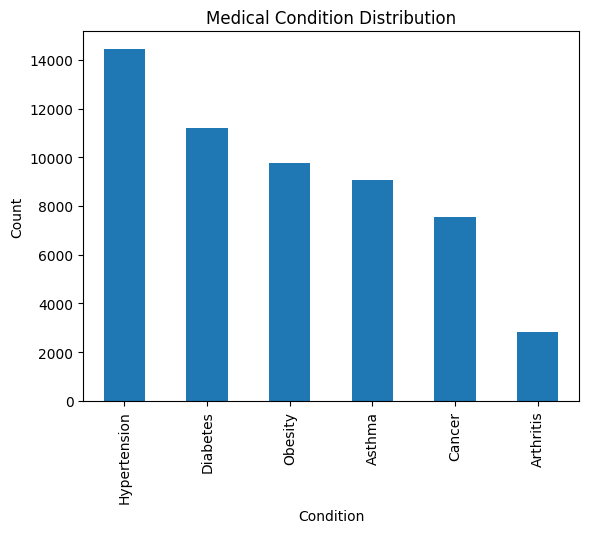

In [167]:
df['Medical Condition'].value_counts().plot(kind='bar')  # Bar chart for condition count
plt.title('Medical Condition Distribution')  # Chart title
plt.xlabel('Condition')  # Label x-axis
plt.ylabel('Count')  # Label y-axis
plt.show()  # Display the chart

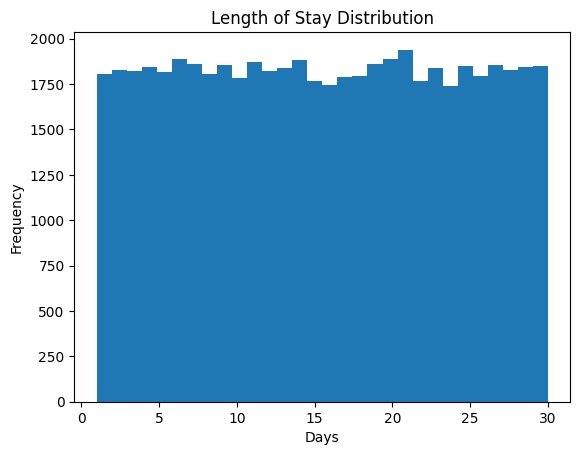

In [168]:
df['Length of Stay'].plot(kind='hist', bins=30)  # Histogram for length of stay
plt.title('Length of Stay Distribution')  # Chart title
plt.xlabel('Days')  # Label x-axis
plt.ylabel('Frequency')  # Label y-axis
plt.show()  # Display the chart

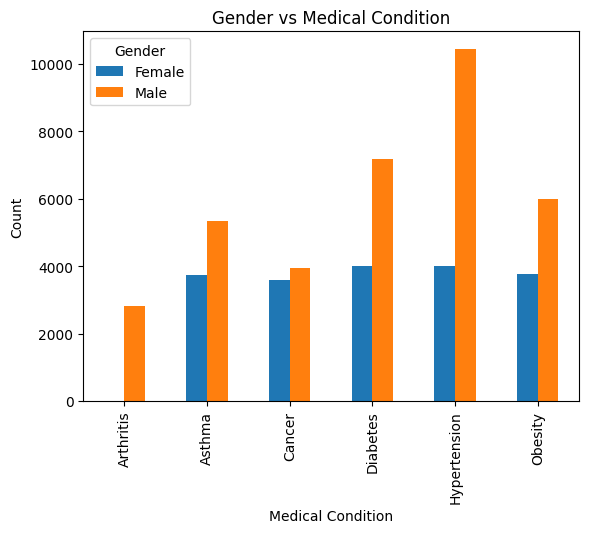

In [169]:
pd.crosstab(df['Medical Condition'], df['Gender']).plot(kind='bar')  # Compare gender across conditions
plt.title('Gender vs Medical Condition')  # Chart title
plt.xlabel('Medical Condition')  # X-axis label
plt.ylabel('Count')  # Y-axis label
plt.show()  # Display chart

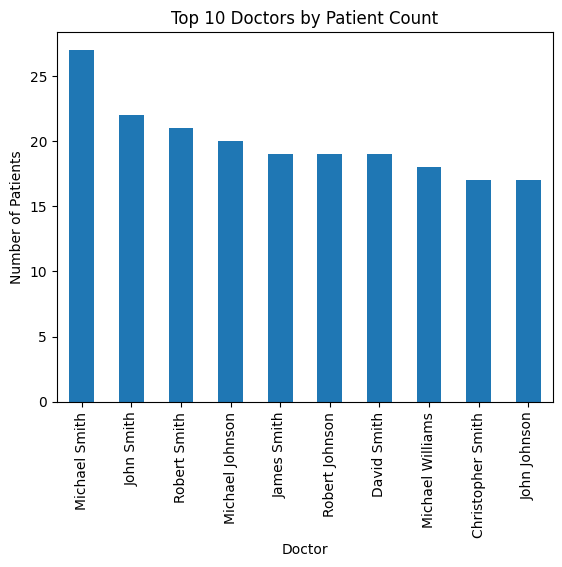

In [170]:
df['Doctor'].value_counts().head(10).plot(kind='bar')  # Top 10 doctors by patient count
plt.title('Top 10 Doctors by Patient Count')  # Chart title
plt.xlabel('Doctor')  # X-axis label
plt.ylabel('Number of Patients')  # Y-axis label
plt.show()  # Display chart

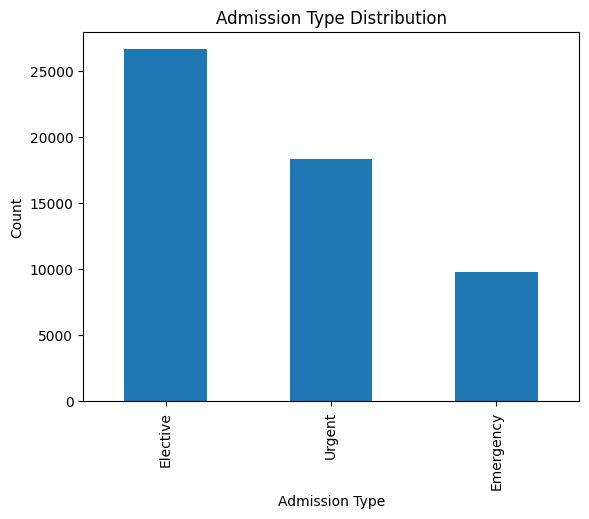

In [171]:
df['Admission Type'].value_counts().plot(kind='bar')  # Count of each admission type
plt.title('Admission Type Distribution')  # Chart title
plt.xlabel('Admission Type')  # X-axis label
plt.ylabel('Count')  # Y-axis label
plt.show()  # Display chart

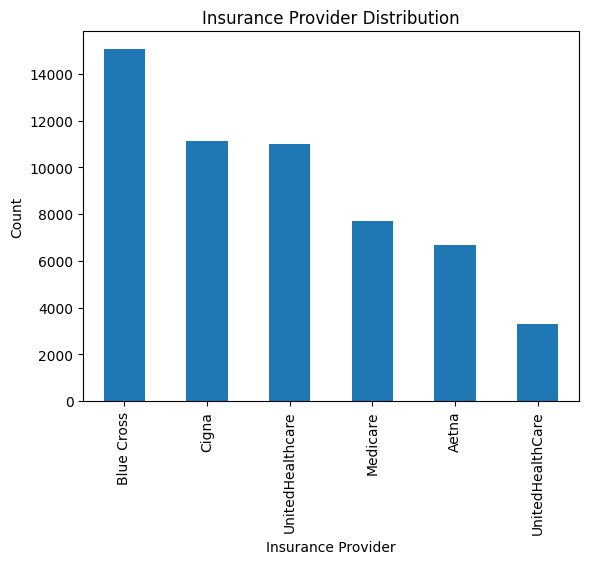

In [172]:
df['Insurance Provider'].value_counts().plot(kind='bar')  # Count per insurance provider
plt.title('Insurance Provider Distribution')  # Chart title
plt.xlabel('Insurance Provider')  # X-axis label
plt.ylabel('Count')  # Y-axis label
plt.show()  # Display chart

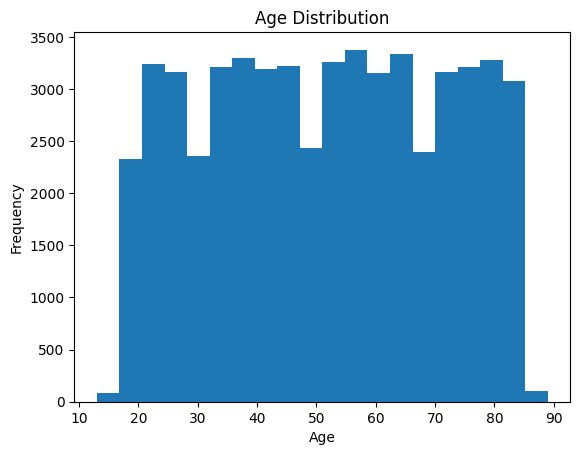

In [173]:
df['Age'].plot(kind='hist', bins=20)  # Age distribution
plt.title('Age Distribution')  # Chart title
plt.xlabel('Age')  # X-axis label
plt.ylabel('Frequency')  # Y-axis label
plt.show()  # Display chart

In [174]:
df['Year'] = df['Date of Admission'].dt.year  # Extract year from admission date

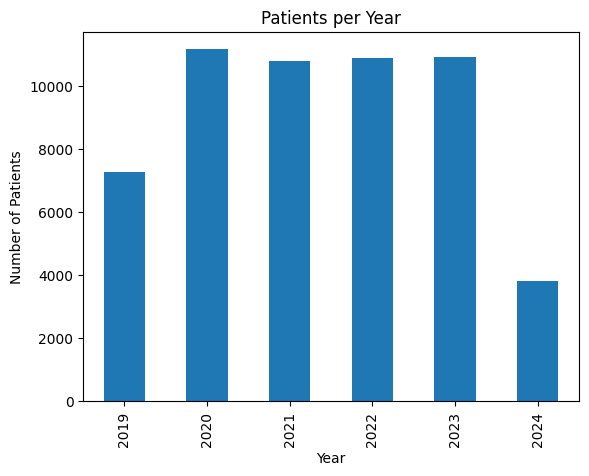

In [175]:
df['Year'].value_counts().sort_index().plot(kind='bar')  # Count patients per year
plt.title('Patients per Year')  # Chart title
plt.xlabel('Year')  # X-axis label
plt.ylabel('Number of Patients')  # Y-axis label
plt.show()  # Display chart

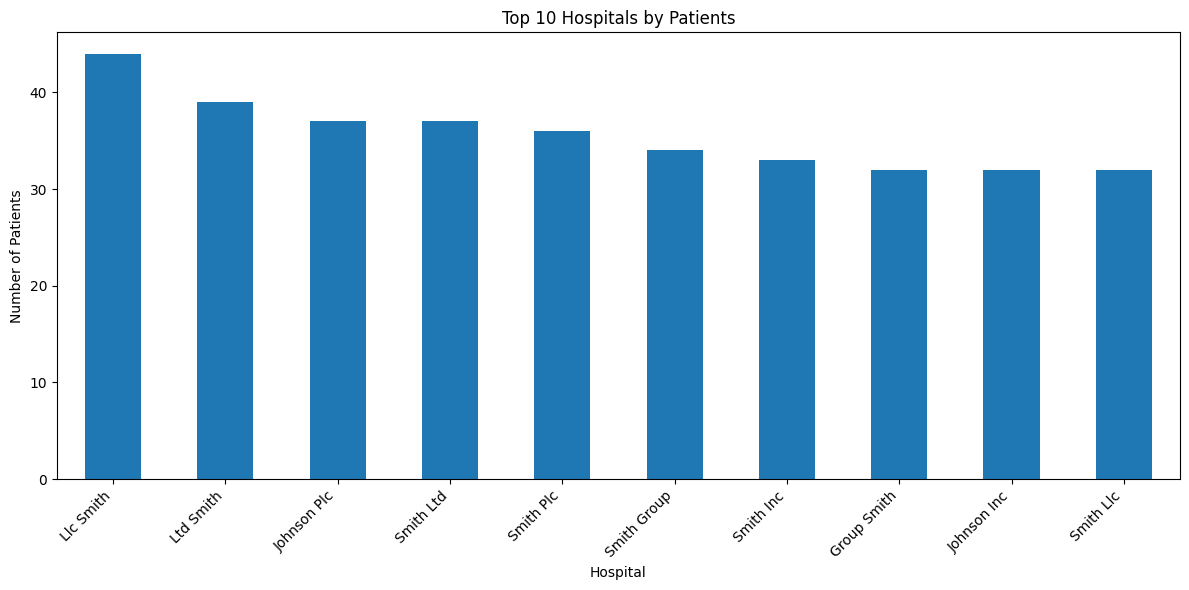

In [176]:
import matplotlib.pyplot as plt  # Import plotting library

plt.figure(figsize=(12,6))  # Increase figure size for better spacing

df['Hospital'].value_counts().head(10).plot(kind='bar')  # Top 10 hospitals by patient count

plt.title('Top 10 Hospitals by Patients')  # Chart title
plt.xlabel('Hospital')  # X-axis label
plt.ylabel('Number of Patients')  # Y-axis label

plt.xticks(rotation=45, ha='right')  # Rotate labels to avoid overlap

plt.tight_layout()  # Adjust spacing to prevent cut/overlap
plt.show()  # Display chart

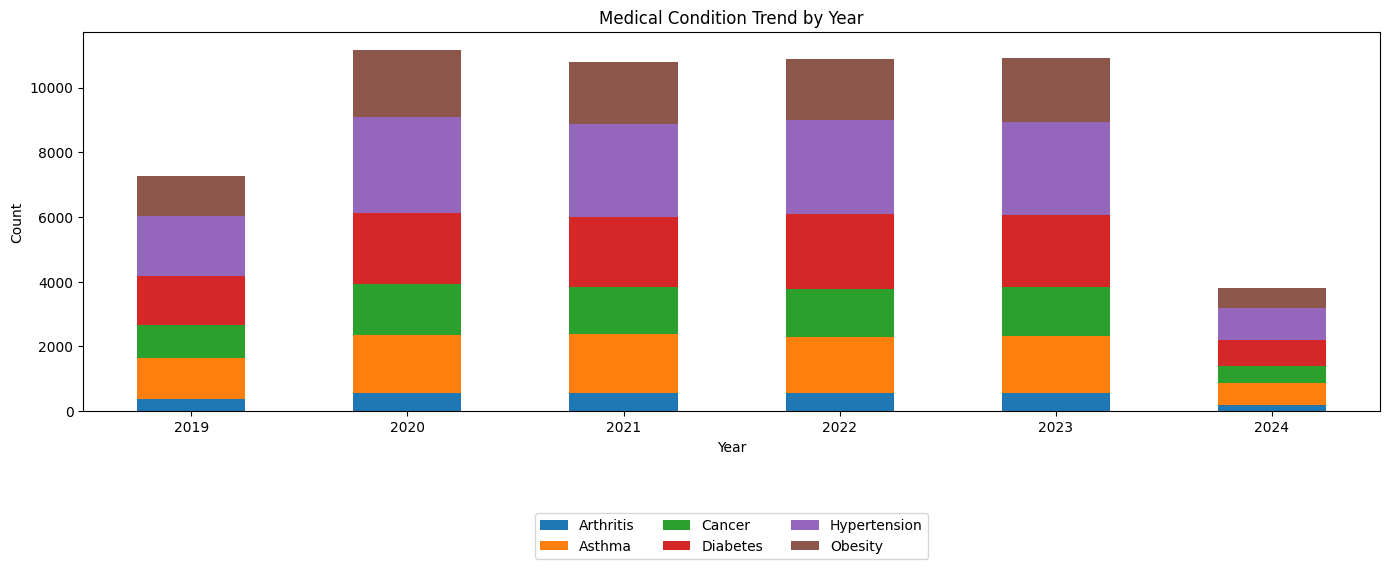

In [177]:
pd.crosstab(df['Year'], df['Medical Condition']).plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)  # Increase width (main fix)
)

plt.title('Medical Condition Trend by Year')  # Chart title
plt.xlabel('Year')  # X-axis label
plt.ylabel('Count')  # Y-axis label

plt.xticks(rotation=0)  # Keep years straight (important)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3)
# Move legend further down

plt.tight_layout()  # Adjust layout
plt.show()

print("\n\n\n\n")  # Spacing for PDF

In [178]:
df.to_csv('cleaned_healthcare_data.csv', index=False)  # Save file in Colab environment

In [179]:
from google.colab import files
files.download('cleaned_healthcare_data.csv')  # Download to your computer

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>